# Discriminatory Analysis

The goal of this final step is to turn our cleaned data matrix into a **ranked** **biomarker** panel that discriminates lung cancer (French), benign disease (LMU) and healthy (Dunn).

To discover biomarkers, we will use several methods allowing us to use statistical significance, predictive power and decision boundaries as tools. We will also use these tools to report the relative importance of each discovered biomarker.

In [1]:
# Imports

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical methods
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Machine Learning methods
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Personal helpers
from helpers import *

In [2]:
# Display all rows and columns in the DataFrame
# Comment if effect unwanted
pd.set_option('display.max_rows', None)  # No limit on number of rows
pd.set_option('display.max_columns', None)  # No limit on number of columns
pd.set_option('display.width', None)  # Auto-adjust the width
pd.set_option('display.max_colwidth', None)  # Show full content of each column

In [3]:
# Load datasets: Cleaned Data Matrix, Feature Metadata, Acquisition List, Exogenous Standards
clean_data_matrix = pd.read_csv("./data/input/clean_data_matrix.csv")
feature_metadata = pd.read_csv("./data/input/internship_feature_metadata.csv")
acquisition_list = pd.read_csv("./data/input/intership_acquisition_list.csv")
exogenous_stds = pd.read_csv("./data/input/exogenous_standards.csv")

# Set index columns to ensure consistent sample/feature alignment across datasets   
clean_data_matrix = clean_data_matrix.set_index('sample')         
feature_metadata = feature_metadata.set_index('feature')  
acquisition_list = acquisition_list.set_index('sample')    
exogenous_stds = exogenous_stds.set_index('compound_id')  

# Print shape of data frames
print(f"Shape of Cleaned Data Matrix: {clean_data_matrix.shape}")
print(f"Shape of Feature Metadata: {feature_metadata.shape}")
print(f"Shape of Acquisition List: {acquisition_list.shape}")
print(f"Shape of Exogenus Standards: {exogenous_stds.shape}")

Shape of Cleaned Data Matrix: (101, 156)
Shape of Feature Metadata: (252, 10)
Shape of Acquisition List: (124, 4)
Shape of Exogenus Standards: (4, 2)


In [4]:
# Keep only the biological samples
bio_data = clean_data_matrix.loc[acquisition_list['class'].isin(['French', 'Dunn', 'LMU'])]
bio_data_types = bio_data.join(other=acquisition_list)

# Get features of interest
features = bio_data.columns

## Biomarker Discovery using Statistical Significance

In this section, we will:
- For each feature, run FDR-corrected ANOVA across 3 groups (biological sample classes). This will filter for features that show any class-level difference.
- Post-hoc pairwise tests (Tukey's HSD) to see which groups drive each signal. This will identify which pairs of classes are separated per feature. We will use this to only keep features that separate at least one pair of classes significantly.

### ANOVA

As described in the paper [Understanding one-way ANOVA using conceptual figures](https://pubmed.ncbi.nlm.nih.gov/28184262/), to determine the differences in the means of 3 or more groups that are mutually independent and satisfy both the normality and equal variance assumptions, the most common analytical method is the one-way analysis of variance (ANOVA).

In this section, we will perform ANOVA for each feature across the three biological classes: Lung Cancer (French), Benign Disease (LMU), and Healthy (Dunn).

In [5]:
# Perform one-way ANOVA

# Run ANOVA for each feature across the three groups (i.e. biological classes)
anova_results = {}
for feature in features:
    # Keep the measurements for this specific feature
    temp_bio_data = bio_data[feature]
    
    # Separate the data into 3 groups: French (Lung Cancer), Dunn (Healthy) and LMU (Benign Disease)
    french = temp_bio_data[bio_data_types['class'] == 'French']
    dunn =  temp_bio_data[bio_data_types['class'] == 'Dunn']
    lmu = temp_bio_data[bio_data_types['class'] == 'LMU']
    
    # Run ANOVA for this feature across the 3 groups
    F = f_oneway(french, dunn, lmu)
    
    # Save the statistics and pvalues of the ANOVA for each feature
    anova_results[feature] = [F.statistic, F.pvalue]

# Save the results in a dataframe
features_stats = pd.DataFrame(anova_results)
features_stats.index = ['statistic', 'p_value']
features_stats = features_stats.T

# Sort the data frame by p value
features_stats = features_stats.sort_values(by='p_value')

### FDR Correction

As explained in the paper [FDR adjustments of Microarray Experiments](https://www.bioconductor.org/packages/release/bioc/vignettes/fdrame/inst/doc/fdrame.pdf), the False Discovery Rate (FDR) criterion is the expected proportion of erroneously rejected null hypotheses among the rejected ones. 

FDR correction allows to adjust the p-values generated in multiple hypothesis testing. It applies multiple testing procedures that control the FDR criterion introduced by Benjamini and Hochberg (1995). It applies both theoretical-distribution-based and resampling-based multiple testing procedures, and presents as output adjusted p-values.

In our analysis, we ran many tests (one per feature), so we should control for false discoveries (false positives) using the Benjamini-Hochberg correction (i.e. FDR correction).

In [6]:
# Adjust pvalues by BEnjamini-Hochberg (bh) FDR Correction
_, pvals_corrected, _, _ = multipletests(features_stats['p_value'], method='fdr_bh')
features_stats['p_value_adj'] = pvals_corrected
features_stats['significant'] = features_stats['p_value_adj'] < 0.05

# Sort by adjusted pvalue
features_stats = features_stats.sort_values(by='p_value_adj')

Number of non-significant features for biomarker discovery after FDR-corrected ANOVA: 24
Number of significant features for biomarker discovery after FDR-corrected ANOVA: 132


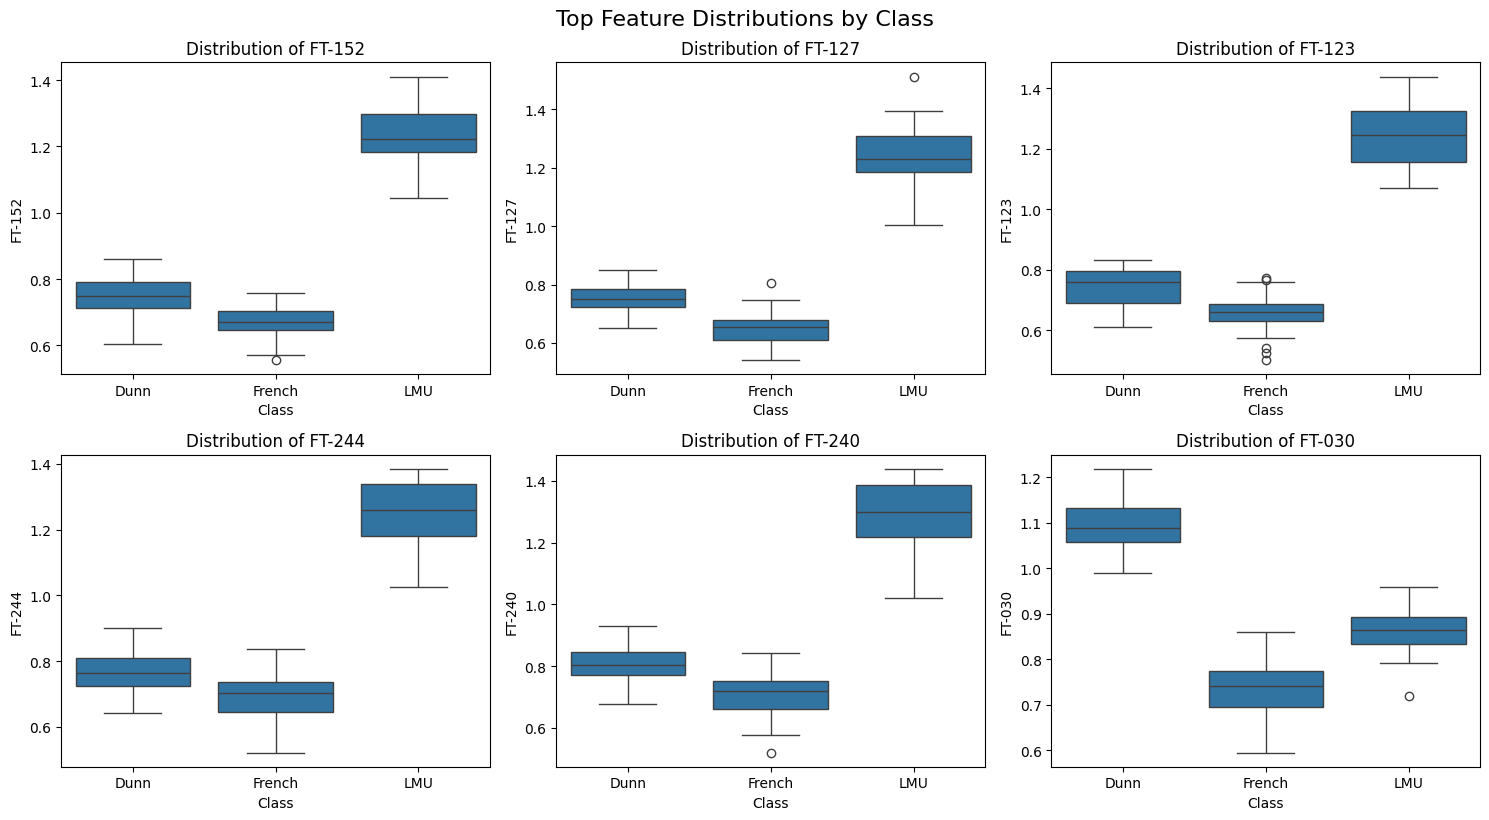

In [7]:
# Print the number of significant vs non-significant features identified through FDR-corrected ANOVA
fdr_anova_features = list(features_stats[features_stats['significant']].index)
print(f"Number of non-significant features for biomarker discovery after FDR-corrected ANOVA: {len(features_stats) - len(fdr_anova_features)}")
print(f"Number of significant features for biomarker discovery after FDR-corrected ANOVA: {len(fdr_anova_features)}")

# Plot boxplots of top 9 features for visualization purposes
top_features = fdr_anova_features[:6]  # e.g., limit to top 9 features for a 3x3 grid
n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # auto calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(ax=axes[i], x=bio_data_types['class'], y=bio_data[feature])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Top Feature Distributions by Class", fontsize=16, y=1.02)
plt.show()


This boxplot visualization shows the distribution of the top 6 features (FT-152, FT-127, FT-123, FT-244, FT-240, FT-030) across the three biological classes: Dunn (Healthy), French (Lung Cancer), and LMU (Benign Disease).

- All six features display clear class separation, with non-overlapping or minimally overlapping distributions across groups.
- LMU consistently shows higher values across FT-152, FT-127, FT-123, FT-244, and FT-240, while French samples show the lowest values.
- Dunn has the highest values for feature FT-030, and French the lowest, indicating it may be more suited to distinguishing Healthy vs Disease.

In [8]:
# Filter the features statistics dataframe for significant features only
features_stats = features_stats[features_stats['significant']]

# Filter the biological data matrix for significant features only
significant_features_data = bio_data[fdr_anova_features]
significant_features_data_types = significant_features_data.join(other=acquisition_list)

### Post-Hoc Tests

When an analysis of variance (ANOVA) gives a significant result, this indicates that at least one group differs from the other groups. But as explained in the [Tukey’s Honestly Significant Difference (HSD) Test](https://personal.utdallas.edu/~herve/abdi-HSD2010-pretty.pdf) paper, this analysis does
not inform on the pattern of differences between the means. For that purpose, the ANOVA is often followed by specific comparisons, and the most commonly used involves comparing two means (the so
called “pairwise comparisons”).

An easy and frequently used pairwise comparison technique was developed by
Tukey under the name of the honestly significant difference (HSD) test. The main
idea of the HSD is to compute the honestly significant difference between two means using a statistical distribution defined by Student and called
the q distribution.

In our analysis, to understand which groups differ per feature, we run a post-hoc test using Tukey's HSD.

In [9]:
tukey_features = {}

for feature in fdr_anova_features:
    tukey = pairwise_tukeyhsd(endog=significant_features_data[feature],
                               groups=significant_features_data_types['class'],
                               alpha=0.05)
    
    # Convert results to a list of rows
    tukey_results = tukey.summary().data[1:]

    # Track which pairs are significant
    significant_pairs = []

    for row in tukey_results:
        group1, group2, meandiff, p_adj, lower, upper, reject = row
        if reject: # the null hypothesis is rejected --> the difference is significant
            significant_pairs.append((group1, group2))

    # Save any significant pairs
    if significant_pairs:
        tukey_features[feature] = significant_pairs

In [10]:
# Create a list for the separation of each pair of classes
dunn_vs_french = []
dunn_vs_lmu = []
french_vs_lmu = []

# Loop through the features. 
# If a pair of classes is significantly separated in Tukey's HSD, add 'True' to the list
for feature in tukey_features:
      sep = tukey_features[feature]
      if (('Dunn', 'LMU') in sep) or (('LMU', 'Dunn') in sep): 
            dunn_vs_lmu.append(True)
      else: 
            dunn_vs_lmu.append(False)
      
      if (('Dunn', 'French') in sep) or (('French', 'Dunn') in sep): 
            dunn_vs_french.append(True)
      else: 
            dunn_vs_french.append(False)
            
      if (('French', 'LMU') in sep) or (('LMU', 'French') in sep): 
            french_vs_lmu.append(True)
      else: 
            french_vs_lmu.append(False)

In [11]:
# Add information on whether each pair of classes is separated significantly by each feature
features_stats['Separates Healthy vs Benign Disease'] = dunn_vs_lmu
features_stats['Separates Healthy vs Lung Cancer'] = dunn_vs_french
features_stats['Separates Lung Cancer vs Benign Disease'] = french_vs_lmu

# Only keep features for which at least 2 pairs of classes are significantly separated (arbitrary)
significant_features = []
for index, row in features_stats.iterrows():
    score = int(row['Separates Healthy vs Benign Disease']) + int(row['Separates Healthy vs Lung Cancer']) + int(row['Separates Lung Cancer vs Benign Disease'])
    if score >= 2:
        significant_features.append(index)

# Print the number of features we keep and the number of features we don't keep
print(f"Number of significant features after FDR-corrected ANOVA and Tukey's HSD: {len(significant_features)}")
print(f"Number of non-significant features after FDR-corrected ANOVA and Tukey's HSD: {len(features_stats) - len(significant_features)}")

Number of significant features after FDR-corrected ANOVA and Tukey's HSD: 106
Number of non-significant features after FDR-corrected ANOVA and Tukey's HSD: 26


In [12]:
# Filter the features statistics dataframe for significant features only
features_stats = features_stats.loc[significant_features]

# Filter the biological data matrix for significant features only
significant_features_data = significant_features_data[list(features_stats.index)]
significant_features_data_types = significant_features_data.join(other=acquisition_list)
print(f"Consistency Check: {significant_features_data.shape[1] == len(significant_features)}")

Consistency Check: True


## Biomarker Discovery: Predictive Power

In this part, we will check whether we can build a classifier using the significant feature, assess the classifier's accuracy, and identify the features that have the highest predictive power.

To do this, we run a Random Forest Classifier (RF), then an L1-regularized logistic regression (LASSO).

### Random Forest

We use this classifier because it can capture nonlinear relationships. This is helpful since biological data has complex relationships. Also, Random Forest naturally ranks features based on how useful they for splitting decisions during training. This will help us identifying and ranking the most biolgically relevant features, i.e. biomarkers.

Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000 ± 0.0000


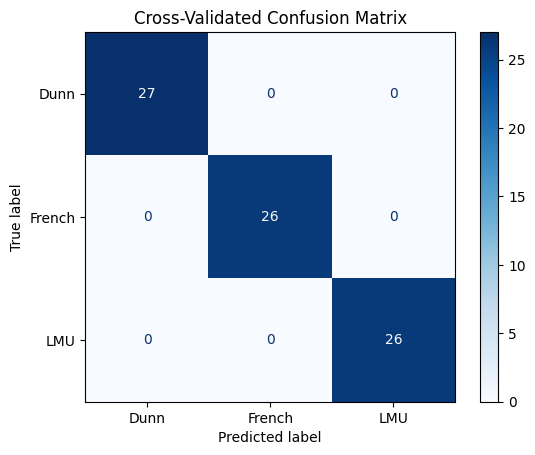

              precision    recall  f1-score   support

        Dunn       1.00      1.00      1.00        27
      French       1.00      1.00      1.00        26
         LMU       1.00      1.00      1.00        26

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [13]:
# Ranfom Forest Classifier (RF)

# Prepare data
X = significant_features_data 
label_encoder = LabelEncoder() # use a label encoder to encode string classes into ints
y = label_encoder.fit_transform(significant_features_data_types['class'])

clf1 = random_forest_classifier(X, y, label_encoder, split=False)

As we can see, the prediction accuracy is 100%. This raises a red flag, since usually, a prediction accuracy of 100% could indicate overfitting. To try and mitigate this effect, we separate the data into training and testing sets.

Test Accuracy: 1.0000


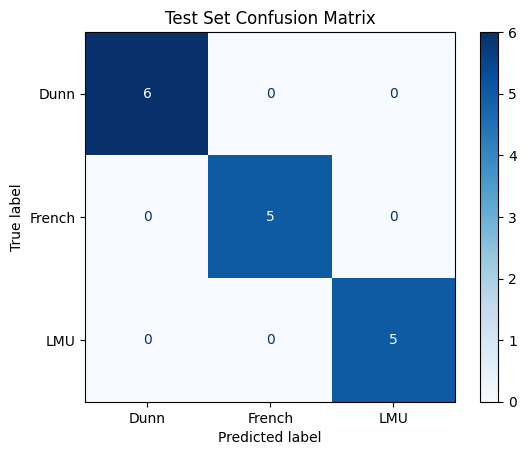

              precision    recall  f1-score   support

        Dunn       1.00      1.00      1.00         6
      French       1.00      1.00      1.00         5
         LMU       1.00      1.00      1.00         5

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [14]:
# Ranfom Forest Classifier (RF) with train-test split
clf2 = random_forest_classifier(X, y, label_encoder, split=True)

These are the results from the test dataset. As we can see, the accuracy is of 100% again. This could mean many things:
- There is overfitting due to our dataset being very small.
- Or our 3 classes are very well separated in feature space, meaning the model achieves perfect separation. We can check this further by looking at PCA and LDA plots. If this is true, these plots will show clear clusters.

Now, we will look at feature importance. We will use the Random Forest Classifier from the train-test split confifuration.

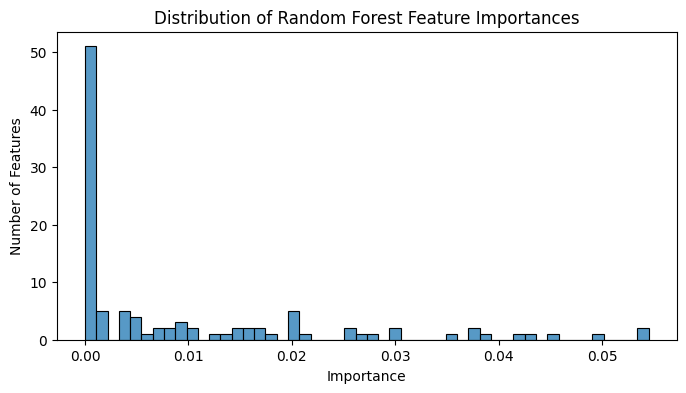

In [15]:
# Report importances of features from random forest classifier
rf_importances = clf2.feature_importances_

plt.figure(figsize=(8, 4))
sns.histplot(rf_importances, bins=50, kde=False)
plt.title("Distribution of Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Number of Features")
plt.show()

The distribution of Random Forest Feature importances shows that many features have near-zero importance. This raises an interesting question: why might statistically significant features have low imprtance in random forest? One of the most convincing answers is: **redundancy between features**.

Many statistically-selected features could be correlated, so once the random forest classifier uses one, others become less useful for splitting.

Since we have 106 features, and the feature importances are relative scores that sum to 1.0, a completely uniform importance would be 1/106 ~ 0.01.

For this reason, we will get rid of features that have importance lower than 0.01.

In [16]:
# Create a pandas series with feature names as index and feature importances as values
rf_importances = pd.Series(clf2.feature_importances_, index=X.columns)

# Filter the series for important features only (i.e. features with importance >= 0.01)
top_rf_importances = rf_importances[rf_importances >= 0.01]
print(f"Number of features with importance > 0.01 for Random Forest Classifier: {len(top_rf_importances)}")

Number of features with importance > 0.01 for Random Forest Classifier: 32


### L1-regularied Logistic Regression

We use this classifier because it offers strengths for feature selection and model interpretability. LASSO applies an L1 pealty to the logistic regression model, encouraging many coefficients to shrink to exactly zero. This means only the most predicitv features remain active, and we automatically get a smaller, interpretable biomarker panel.

/Users/aishamasmoudi/opt/anaconda3/envs/isospec/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1903: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 1.0000


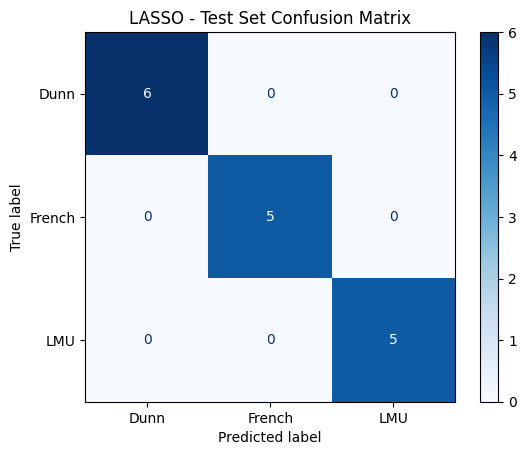

              precision    recall  f1-score   support

        Dunn       1.00      1.00      1.00         6
      French       1.00      1.00      1.00         5
         LMU       1.00      1.00      1.00         5

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [17]:
X = significant_features_data
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(significant_features_data_types['class'])

lasso = lasso_classifier(X, y, label_encoder, split=True)

As we can see, the accuracy is of 100%, like the random forest classifier. We can consider the same conclusions, i.e. that we either overfit because the dataset is too small, or that the data is perfectly separable.

Now, we look at feature importance.

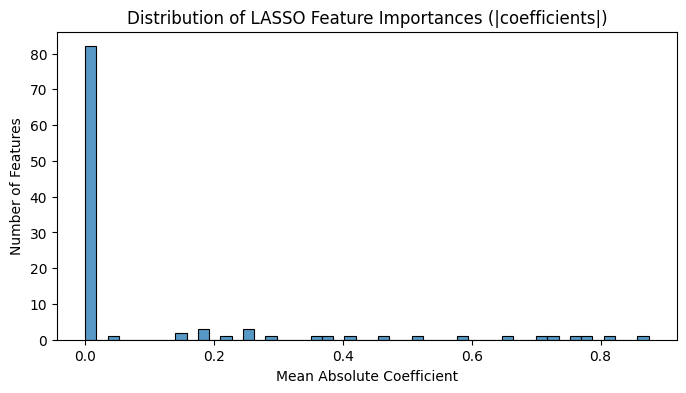

In [18]:
# Get the logistic regression model from the pipeline
logreg = lasso.named_steps['logisticregressioncv']

# Get coefficients: shape (n_classes, n_features)
coefs = logreg.coef_

# Calculate average absolute importance across all classes
lasso_importances = np.mean(np.abs(coefs), axis=0)

# Plot distribution of importances
plt.figure(figsize=(8, 4))
sns.histplot(lasso_importances, bins=50, kde=False)
plt.title("Distribution of LASSO Feature Importances (|coefficients|)")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Number of Features")
plt.show()

LASSO automatically sets some coefficients to zero, thanks to L1 regularization. The remaining non-zero coefficients are considered "selected" features. We therefore choose important features as those who have importance strictly bigger than 0.

In [19]:
# Create a pandas series with feature names as index and feature importances as values
lasso_importances = pd.Series(lasso_importances, index=X.columns)

# Filter the series for important features only (i.e. features with importance > 0)
top_lasso_importances = lasso_importances[lasso_importances >= 0.01]
print(f"Number of features with importance > 0 for LASSO: {len(top_lasso_importances)}")

Number of features with importance > 0 for LASSO: 25


### Common Features between RF and LASSO

Now that we have identified the most important features from RF and LASSO, let's define a dataframe with the identified features, and their importance scores on both RF and LASSO. If a feature was selected in one method and not the other, the importance score will be 'NaN'.

In [20]:
# Initialize dict to store feature importances from both models
top_features_dict = {}

for feature in significant_features:
    rf_val = top_rf_importances[feature] if feature in top_rf_importances else None
    lasso_val = top_lasso_importances[feature] if feature in top_lasso_importances else None
    top_features_dict[feature] = {'RF Importance': rf_val, 'LASSO Importance': lasso_val}

# Convert to DataFrame
top_features_df = pd.DataFrame.from_dict(top_features_dict, orient='index')

# Consistency check
print(f"Correct number of features for LASSO: {len(top_features_df['LASSO Importance'].dropna()) == len(top_lasso_importances)}")
print(f"Correct number of features for RF: {len(top_features_df['RF Importance'].dropna()) == len(top_rf_importances)}")

Correct number of features for LASSO: True
Correct number of features for RF: True


Now, we keep only the features that are important in both RF and LASSO.

In [21]:
biomarkers = []
for index, row in top_features_df.iterrows():
    # Only keep a feature if it is important in both RF and LASSO
    if (pd.isna((row['RF Importance'])) == False) & (pd.isna(row['LASSO Importance']) == False):
        biomarkers.append(index)
        
# Filter data matrix for biomarkers
biomarker_data = significant_features_data.copy()
biomarker_data = biomarker_data[biomarkers]
biomarker_data_types = biomarker_data.join(other=acquisition_list)
print(f"Number of significant features for both RF and LASSO: {len(biomarkers)}")

Number of significant features for both RF and LASSO: 13


## Biomarker Discovery: Decision Boundaries

After reducing our data to 13 robust biomarkers using statistical significance (FDR-ANOVA and Tukey) and predictive power (Random Forest and LASSO), we want to visualize decision boundaries. i.e. check how well these biomarkers separate the three classes. 

To do this, we perform Principal Component Analysis (PCA) then Linear Dsicriminant Analysis (LDA).

### LDA

LDA projects data onto the space that maximally separates classes.

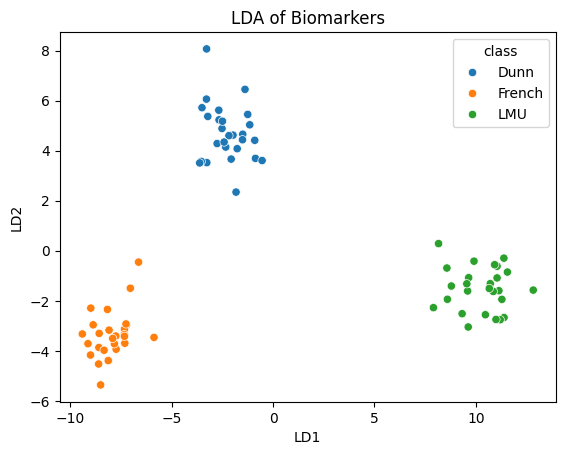

In [22]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(biomarker_data,
                          biomarker_data_types['class'])
df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['class'] = biomarker_data_types['class'].values

sns.scatterplot(data=df_lda, x='LD1', y='LD2', hue='class')
plt.title("LDA of Biomarkers")
plt.show()

The LDA projection plot shows how well our data, based on your 13 selected biomarkers, separates the three biological classes: Dunn (Healthy), French (Lung Cancer), and LMU (Benign Disease).

- LD1 and LD2 are linear combinations of our 13 biomarkers that best separate the classes. Each point is a sample, positioned based on its LDA projection.
- All three classes are well separated.
- LD1 appears to separate French (Lung Cancer) from LMU (Benign) and Dunn (Healthy). LD2 apepars to separate Dunn from the other two.

This confirms that our 13 selected features are highly discriminative.

We now report magnitudes of LDA loading to determine feature importance. Indeed, the higher the LDA magnitude, the more discriminative the feature is.

In [23]:
# Get LDA loadings (feature contributions to LD axes)
lda_loadings = pd.DataFrame(lda.scalings_,  # shape: (n_features, n_components)
                            index=biomarker_data.columns,
                            columns=['LD1', 'LD2'])

# Add magnitude for ranking
lda_loadings['lda magnitude'] = (lda_loadings**2).sum(axis=1)**0.5

### PCA

PCA reduces the 13-dimensional biomarker space into two principal components (PC1 and PC2) that capture the most variance in the data without using class labels. It provides an unsupervised way to visualize how samples cluster based on overall expression patterns.

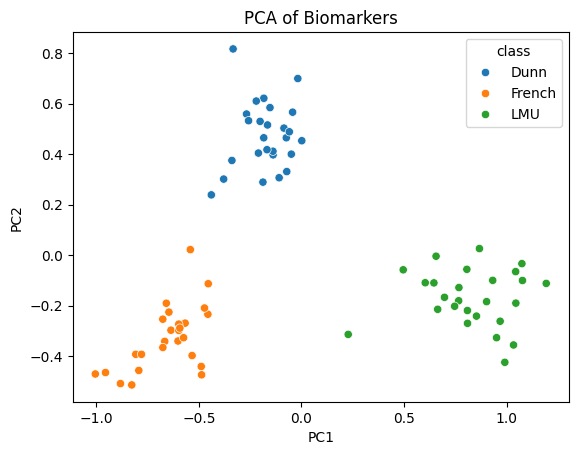

In [24]:
### Visualize Class Separation

pca = PCA(n_components=2)
X_pca = pca.fit_transform(biomarker_data)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['class'] = biomarker_data_types['class'].values

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='class')
plt.title("PCA of Biomarkers")
plt.show()

The PCA plot shows the projection of samples based on the 13 selected biomarkers, with each point colored by class: Dunn (Healthy), French (Lung Cancer), and LMU (Benign Disease).

- Clear class separation is observed, especially along PC1, which effectively distinguishes LMU from French and Dunn.
- Dunn and French are further separated along PC2, indicating distinct variance in their biomarker profiles.

The clear separation between the three biological classes in the PCA plot suggests that the selected biomarkers capture meaningful variance that aligns with the class structure, supporting their relevance as potential discriminative features.

We now report magnitudes of PCA loading to determine feature importance. Indeed, the higher the PCA magnitude, the more discriminative the feature is.

In [25]:
# PCA loadings (feature contributions to PCs)
pca_loadings = pd.DataFrame(pca.components_.T,  # transpose to get features as rows
                            index=biomarker_data.columns,
                            columns=['PC1', 'PC2'])

# Add combined magnitude for ranking
pca_loadings['pca magnitude'] = (pca_loadings**2).sum(axis=1)**0.5

## Final Steps

As final steps, we will:
- As a sanity check, look at the distribution of mass-to-charge ratio and retention time of the final biomarkers
- Provide a dataframe (biomarkers panel) with the biomarkers as rows, and important values attached to the biomarkers found during statistical significance, predictive power and decision bounadries analyses, as columns. 
- Investigate a way to define a sense of hierarchy in the final list of targets.

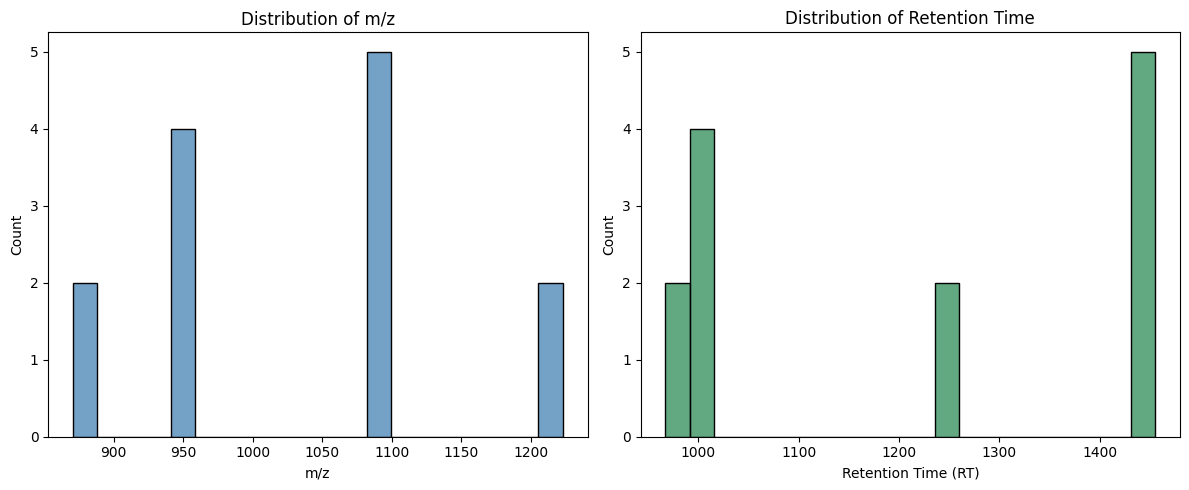

In [26]:
# List of final selected features
final_features = biomarkers  # or your list of 13 final biomarkers

# Merge with metadata (assuming index = feature names)
selected_meta = feature_metadata.loc[final_features]

plt.figure(figsize=(12, 5))

# Subplot 1: Distribution of m/z
plt.subplot(1, 2, 1)
sns.histplot(selected_meta['mz'], bins=20, color='steelblue')
plt.title("Distribution of m/z")
plt.xlabel("m/z")
plt.ylabel("Count")

# Subplot 2: Distribution of Retention Time
plt.subplot(1, 2, 2)
sns.histplot(selected_meta['rt'], bins=20, color='seagreen')
plt.title("Distribution of Retention Time")
plt.xlabel("Retention Time (RT)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

- The m/z values fall into a few distinct clusters, suggesting that multiple biomarkers may have similar or related mass/charge characteristics. This could indicate isomers (same mass but different retention times).

- Similarly, retention times show clustering in specific RT ranges. This could indicate isotopes (same retention time but different mass)

In [27]:
# Final biomarkers panel

# Statistics of biomarkers obtained from statistical significance analysis
features_stats = features_stats.loc[biomarkers]

# Importances of biomarkers obtained from predictive power analysis
top_features_df = top_features_df.loc[biomarkers]

# LDA loadings
lda_loadings

# PCA Loadings
pca_loadings

# Define biomarker panel
biomarker_panel = features_stats.join(other=top_features_df).join(other=lda_loadings).join(other=pca_loadings)

In order to define a sense of hierarchy, we can compute a composite score based on the following four metrics:
- Random Forest Classifier Importance Score
- LASSO Importance Score
- LDA Magnitude
- PCA Magnitude

We decide to give the same importance to all four metrics, by defining the weight of each metric to 0.25.

This is just one idea as to how to define hierarchy, but other methods could be used, such as only ranking based one metric, etc.

In [28]:
# Normalize selected columns
scaler = MinMaxScaler()
biomarker_panel[['RF_norm', 'LASSO_norm', 'LDA_norm', 'PCA_norm']] = scaler.fit_transform(
    biomarker_panel[['RF Importance', 'LASSO Importance', 'lda magnitude', 'pca magnitude']]
)

# Define composite score with adjustable weights (example: equal weight for now)
biomarker_panel['Score'] = (
    0.25 * biomarker_panel['RF_norm'] +
    0.25 * biomarker_panel['LASSO_norm'] +
    0.25 * biomarker_panel['LDA_norm'] +
    0.25 * biomarker_panel['PCA_norm']
)

# Sort biomarkers by overall composite score
biomarker_panel = biomarker_panel.sort_values(by='Score', ascending=False)
biomarker_panel.to_csv("./data/biomarkers/biomarker_panel.csv")

In [29]:
biomarker_panel

,statistic,p_value,p_value_adj,significant,Separates Healthy vs Benign Disease,Separates Healthy vs Lung Cancer,Separates Lung Cancer vs Benign Disease,RF Importance,LASSO Importance,LD1,LD2,lda magnitude,PC1,PC2,pca magnitude,RF_norm,LASSO_norm,LDA_norm,PCA_norm,Score
FT-030,251.530964,3.071610e-34,7.986186e-33,True,True,True,True,0.054523,0.784770,-15.051008,12.202636,19.376201,0.047004,0.420916,0.423532,1.000000,0.875957,1.000000,0.938681,0.953659
FT-016,191.080125,2.250376e-30,4.388232e-29,True,True,True,True,0.053878,0.593205,7.695287,1.228473,7.792727,0.285275,0.254804,0.382501,0.985407,0.611784,0.315530,0.792047,0.676192
FT-027,221.166530,2.069083e-32,4.611100e-31,True,True,True,True,0.041962,0.663454,5.973753,1.756358,6.226598,0.054377,0.425231,0.428694,0.715773,0.708659,0.222987,0.957127,0.651137
FT-127,502.577688,1.524643e-44,1.189222e-42,True,True,True,True,0.030280,0.821038,3.407042,-6.343661,7.200692,0.411294,-0.109688,0.425669,0.451447,0.925971,0.280546,0.946318,0.651071
FT-024,183.368059,8.268149e-30,1.289831e-28,True,True,True,True,0.020298,0.874720,7.644591,2.521109,8.049581,0.058792,0.431040,0.435031,0.225581,1.000000,0.330708,0.979774,0.634016
FT-218,136.800430,6.533739e-26,5.364544e-25,True,True,True,True,0.027330,0.704675,-8.903193,0.640376,8.926193,0.066882,0.435263,0.440372,0.384698,0.765503,0.382507,0.998859,0.632892
FT-240,325.384628,5.468242e-38,1.706092e-36,True,True,True,True,0.049979,0.404296,4.725675,-1.731367,5.032855,0.400597,-0.124234,0.419419,0.897186,0.351274,0.152449,0.923980,0.581222
FT-123,418.441895,9.443385e-42,4.910560e-40,True,True,True,True,0.025909,0.754356,5.358048,-0.026702,5.358115,0.410948,-0.121952,0.428661,0.352555,0.834016,0.171668,0.957010,0.578812
FT-176,190.244916,2.585439e-30,4.481428e-29,True,True,True,True,0.037159,0.380606,2.614355,0.062744,2.615108,0.265868,0.259379,0.371434,0.607107,0.318604,0.009583,0.752497,0.421948
FT-244,382.687084,2.095694e-40,8.173207e-39,True,True,True,True,0.017097,0.457565,5.335806,0.588069,5.368114,0.392657,-0.135811,0.415481,0.153159,0.424732,0.172259,0.909907,0.415014


## Conclusion

In this final step, we identified a robust panel of 13 biomarkers that capture the key biological differences between the three sample classes: **Lung Cancer (French)**, **Benign Disease (LMU)**, and **Healthy (Dunn)**. Our selection was guided by a combination of statistical and predictive criteria:

- **Statistical Significance**: Features were selected through FDR-corrected ANOVA and Tukey’s HSD to ensure reliable group-level differences.
- **Predictive Power**: We retained only those features that were consistently ranked as important by both **Random Forest** and **LASSO** classifiers. These models achieved 100% classification accuracy under cross-validation, indicating strong signal in the selected features.
- **Decision Boundaries**: Clear class separability was confirmed using **LDA**, which showed great discrimination across all three groups. PCA also revealed strong unsupervised clustering of samples.
- **Feature Hierarchy**: To prioritize biomarkers, we computed a composite score combining RF importance, LASSO importance, and contributions to LDA and PCA dimensions. 

Overall, the final biomarker panel is statistically robust, biologically meaningful, and computationally validated to separate the three classes with high confidence.